# Explainable Machine Learning: Comparing Global and Local Explanations

This project compares interpretation methods for linear regression and gradient boosting on the 2021 World Happiness Report data. It examines how scaling affects coefficient-based explanations and contrasts ICE, PDP, ALE, permutation importance, occlusion, SHAP, and LIME.

The emphasis is methodological: different explanation techniques answer different questions and may become unstable outside the data distribution or under changes to their neighbourhood definitions.

## Environment and imports

Dependencies are listed in the repository-level `requirements.txt`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error

In [ ]:
url = "https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=1"
data_to_work = pd.read_csv(url)
data_to_work.head()

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


In [ ]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

In [ ]:
feature_names = list(X.columns)

# Feature selected for detailed analysis
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

In [ ]:
print("Линейные модели")
lr_minmax = LinearRegression()
lr_minmax.fit(X_train_sc_minmax, y_train)
y_pred_lr_minmax = lr_minmax.predict(X_test_sc_minmax)
mse_lr_minmax = mean_squared_error(y_test, y_pred_lr_minmax)
print(f"mse_lr_minmax = {mse_lr_minmax}, rmse_lr_minmax = {np.sqrt(mse_lr_minmax)}")

lr_standard = LinearRegression()
lr_standard.fit(X_train_sc_standard, y_train)
y_pred_lr_standard = lr_standard.predict(X_test_sc_standard)
mse_lr_standard = mean_squared_error(y_test, y_pred_lr_standard)
print(f"lr_standard = {mse_lr_standard}, rmse_lr_standard = {np.sqrt(mse_lr_standard)}")

print()
print("Лассо")
lasso_minmax = Lasso(alpha=0.01)
lasso_minmax.fit(X_train_sc_minmax, y_train)
y_pred_lasso_minmax = lasso_minmax.predict(X_test_sc_minmax)
mse_lasso_minmax = mean_squared_error(y_test, y_pred_lasso_minmax)
print(f"mse_lasso_minmax = {mse_lasso_minmax}, rmse_lasso_minmax = {np.sqrt(mse_lasso_minmax)}")

lasso_standard = Lasso(alpha=0.01)
lasso_standard.fit(X_train_sc_standard, y_train)
y_pred_lasso_standard = lasso_standard.predict(X_test_sc_standard)
mse_lasso_standard = mean_squared_error(y_test, y_pred_lasso_standard)
print(f"mse_lasso_standard = {mse_lasso_standard}, rmse_lasso_standard = {np.sqrt(mse_lasso_standard)}")


print()
print("Градиентный бустинг")
gb_minmax = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_minmax.fit(X_train_sc_minmax, y_train)
y_pred_gb_minmax = gb_minmax.predict(X_test_sc_minmax)
mse_gb_minmax = mean_squared_error(y_test, y_pred_gb_minmax)
print(f"mse_gb_minmax = {mse_gb_minmax}, rmse_gb_minmax = {np.sqrt(mse_gb_minmax)}")

gb_standard = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_standard.fit(X_train_sc_standard, y_train)
y_pred_gb_standard = gb_standard.predict(X_test_sc_standard)
mse_gb_standard = mean_squared_error(y_test, y_pred_gb_standard)
print(f"mse_gb_standard = {mse_gb_standard}, rmse_gb_standard = {np.sqrt(mse_gb_standard)}")



Линейные модели
mse_lr_minmax = 9.84190223510223e-07, rmse_lr_minmax = 0.0009920636186808904
lr_standard = 9.841902235100613e-07, rmse_lr_standard = 0.000992063618680809

Лассо
mse_lasso_minmax = 0.00749305541337327, rmse_lasso_minmax = 0.08656243650321581
mse_lasso_standard = 0.0003443190242940395, rmse_lasso_standard = 0.01855583531652616

Градиентный бустинг
mse_gb_minmax = 0.1529440077767768, rmse_gb_minmax = 0.3910805643045647
mse_gb_standard = 0.15293189925451242, rmse_gb_standard = 0.39106508314411353


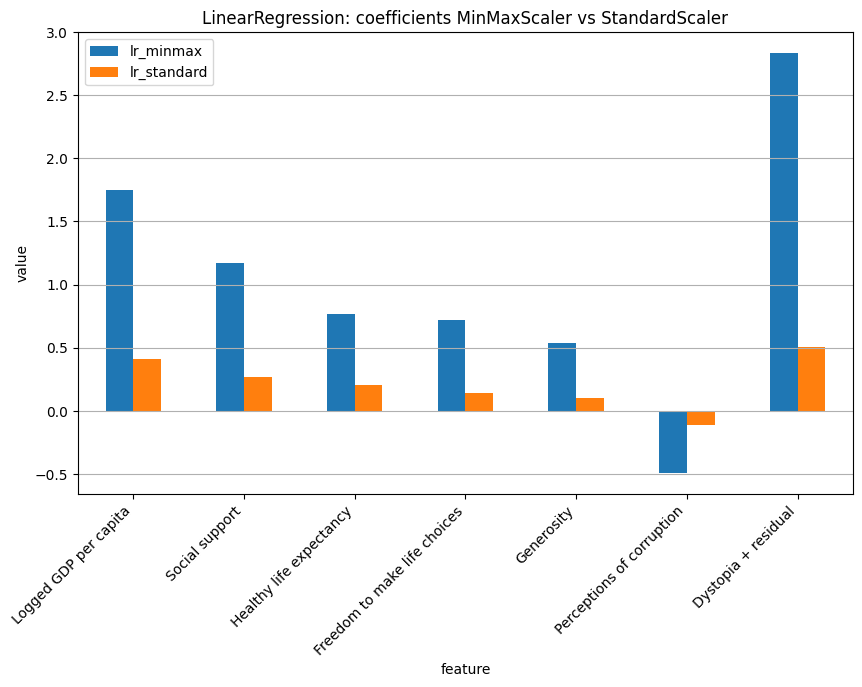

In [ ]:
feature_names = X.columns

lr_coef_df = pd.DataFrame({
    "feature": feature_names,
    "lr_minmax": lr_minmax.coef_,
    "lr_standard": lr_standard.coef_
})


lr_coef_df.set_index("feature").plot(kind="bar", figsize=(10, 6))

plt.title("LinearRegression: coefficients MinMaxScaler vs StandardScaler")
plt.ylabel("value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

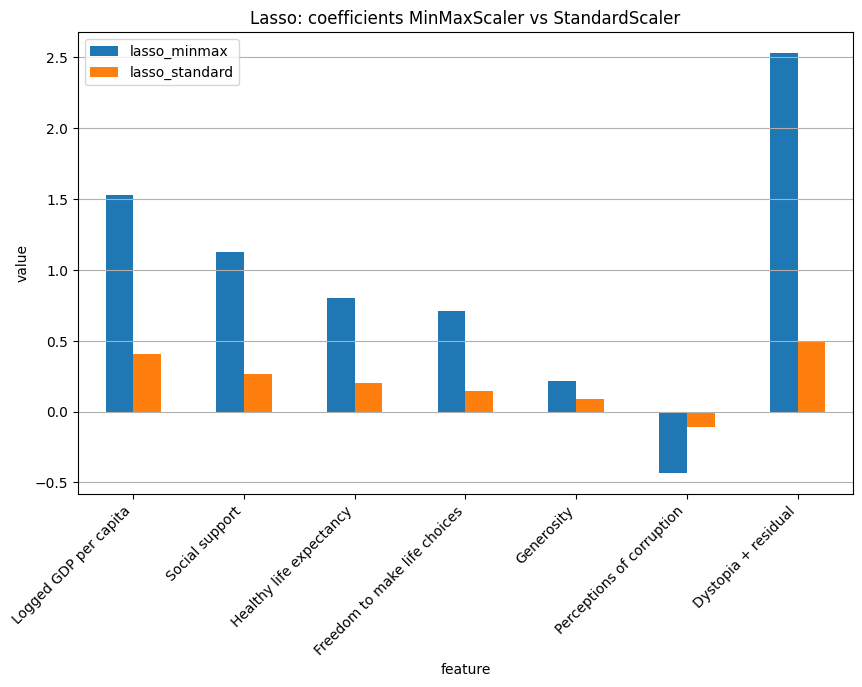

In [ ]:
feature_names = X.columns

lr_coef_df = pd.DataFrame({
    "feature": feature_names,
    "lasso_minmax": lasso_minmax.coef_,
    "lasso_standard": lasso_standard.coef_
})


lr_coef_df.set_index("feature").plot(kind="bar", figsize=(10, 6))

plt.title("Lasso: coefficients MinMaxScaler vs StandardScaler")
plt.ylabel("value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

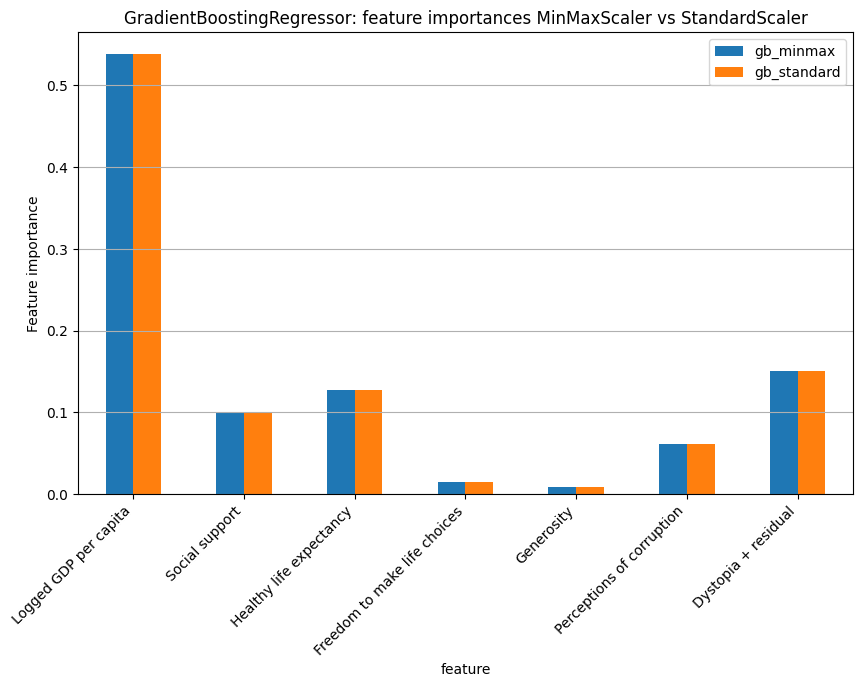

In [ ]:
gb_importance_df = pd.DataFrame({
    "feature": feature_names,
    "gb_minmax": gb_minmax.feature_importances_,
    "gb_standard": gb_standard.feature_importances_
})

gb_importance_df.set_index("feature").plot(kind="bar", figsize=(10, 6))

plt.title("GradientBoostingRegressor: feature importances MinMaxScaler vs StandardScaler")
plt.ylabel("Feature importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## Model performance and scaling sensitivity

Linear regression achieves nearly identical predictive performance under MinMax and standard scaling. Its coefficient magnitudes differ because the units of the transformed features differ. Lasso is more sensitive to scaling because the L1 penalty acts directly on the coefficients. Tree-based gradient boosting is effectively invariant to monotonic linear rescaling.

Across the models, `Dystopia + residual`, `Logged GDP per capita`, and `Social support` receive substantial importance. These values should be interpreted cautiously because one feature is closely tied to the construction of the target; this limitation is discussed below.

## Transforming linear-model coefficients between scalers

For one feature,

$$x_{mm}=\frac{x-x_{min}}{x_{max}-x_{min}}, \qquad x_{sc}=\frac{x-\mu}{\sigma}.$$

Substituting $x=x_{sc}\sigma+\mu$ into the MinMax-scaled model gives

$$\beta^{sc}_j=\beta^{mm}_j\frac{\sigma_j}{x^{max}_j-x^{min}_j}.$$

For multiple features, the intercept becomes

$$b_{sc}=b_{mm}+\sum_j \beta^{mm}_j\frac{\mu_j-x^{min}_j}{x^{max}_j-x^{min}_j}.$$

This conversion illustrates why raw coefficient magnitudes are not absolute measures of importance unless feature scaling is fixed.

In [ ]:
coef_minmax = lr_minmax.coef_
intercept_minmax = lr_minmax.intercept_

mean = sc_standard.mean_
std = sc_standard.scale_

x_range = sc_minmax.data_range_
x_min = sc_minmax.data_min_

coef_std = coef_minmax * (std/x_range)
intercept_std = intercept_minmax + np.sum(coef_minmax * (mean - x_min)/x_range)

results = {
    'lr_standard': [lr_standard]
}


assert round(intercept_std, 4) == round(results['lr_standard'][0].intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(results['lr_standard'][0].coef_, 4))

In [ ]:
lr_minmax =  lr_minmax
gb_minmax =  gb_minmax

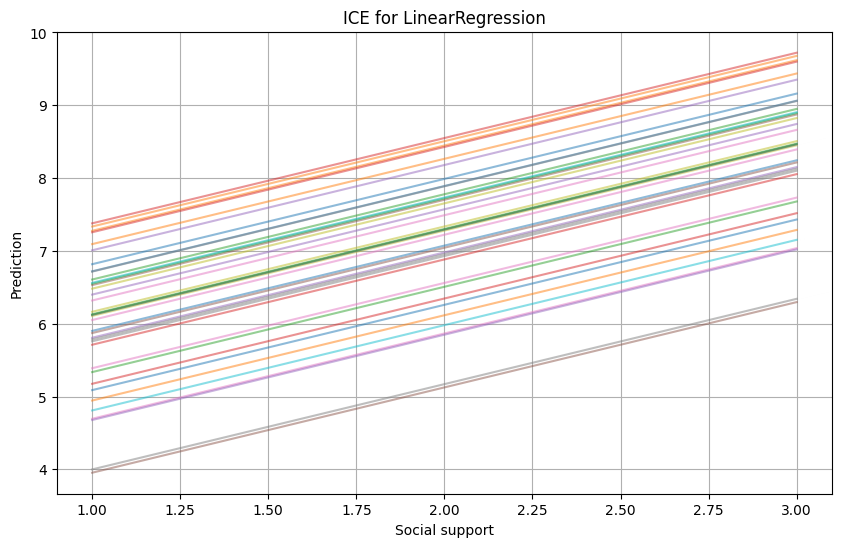

In [ ]:
feature_idx = list(X.columns).index("Social support")

feature_min = X_train_sc_minmax[:, feature_idx].min()
feature_max = X_train_sc_minmax[:, feature_idx].max()

grid = np.linspace(feature_max, 3 * feature_max, 20)

X_ice = X_test_sc_minmax.copy()

ice_lr = []
for value in grid:
    X_temp = X_ice.copy()
    X_temp[:, feature_idx] = value
    y_pred = lr_minmax.predict(X_temp)
    ice_lr.append(y_pred)

ice_lr = np.array(ice_lr)

plt.figure(figsize=(10, 6))
for i in range(ice_lr.shape[1]):
    plt.plot(grid, ice_lr[:, i], alpha=0.5)
plt.title("ICE for LinearRegression")
plt.xlabel("Social support")
plt.ylabel("Prediction")
plt.grid()
plt.show()

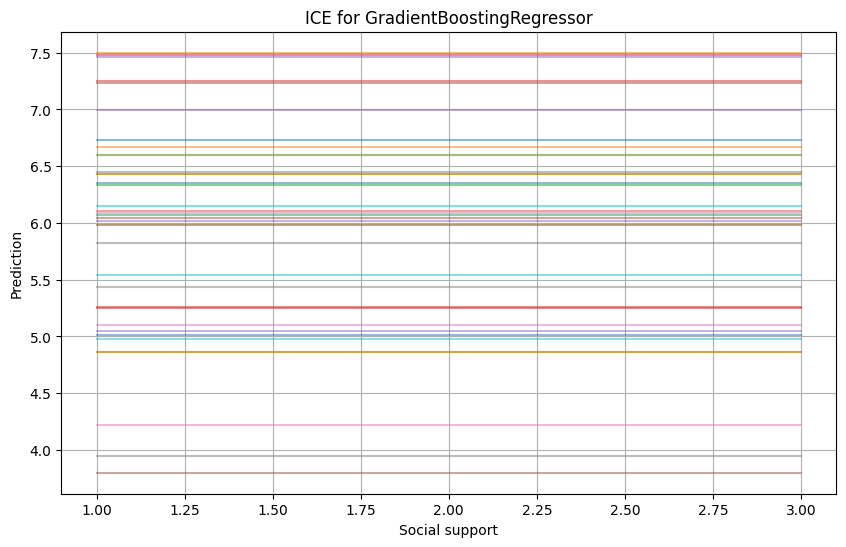

In [ ]:
X_ice = X_test_sc_minmax.copy()

ice_gb = []
for value in grid:
    X_temp = X_ice.copy()
    X_temp[:, feature_idx] = value
    y_pred = gb_minmax.predict(X_temp)
    ice_gb.append(y_pred)

ice_gb = np.array(ice_gb)

plt.figure(figsize=(10, 6))
for i in range(ice_gb.shape[1]):
    plt.plot(grid, ice_gb[:, i], alpha=0.5)
plt.title("ICE for GradientBoostingRegressor")
plt.xlabel("Social support")
plt.ylabel("Prediction")
plt.grid()
plt.show()

## Extrapolation behaviour with ICE

The linear model continues the fitted linear trend outside the observed feature range. This is mathematically consistent but does not guarantee scientifically meaningful extrapolation. The tree-based boosting model instead becomes almost constant: unseen values beyond the largest training threshold are routed to the same terminal leaves.

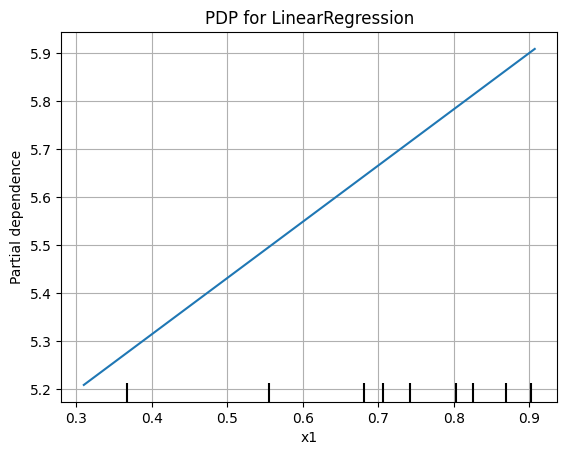

In [ ]:
PartialDependenceDisplay.from_estimator(
    lr_minmax,
    X_test_sc_minmax,
    features=[feature_idx],
    grid_resolution=20
)

plt.title("PDP for LinearRegression")
plt.grid()
plt.show()

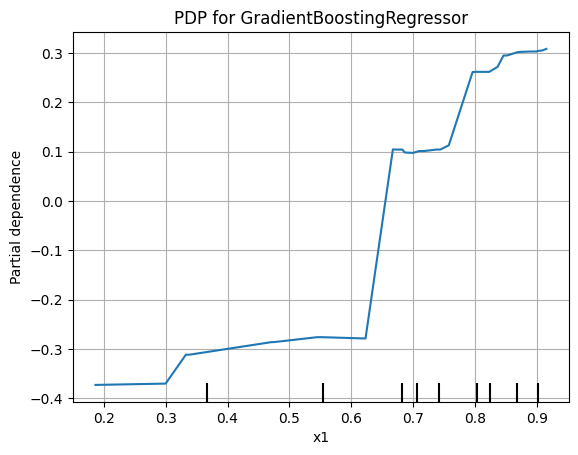

In [ ]:
PartialDependenceDisplay.from_estimator(
    gb_minmax,
    X_test_sc_minmax,
    features=[feature_idx],
    grid_resolution=400
)

plt.title("PDP for GradientBoostingRegressor")
plt.grid()
plt.show()

## Partial dependence

The linear model produces an approximately linear increase in the prediction as `Social support` grows. Gradient boosting produces a non-linear, step-like relationship because its predictions change at learned split thresholds. Increasing grid resolution reveals those thresholds but eventually adds little new information.

PyALE._ALE_generic:INFO: Continuous feature detected.


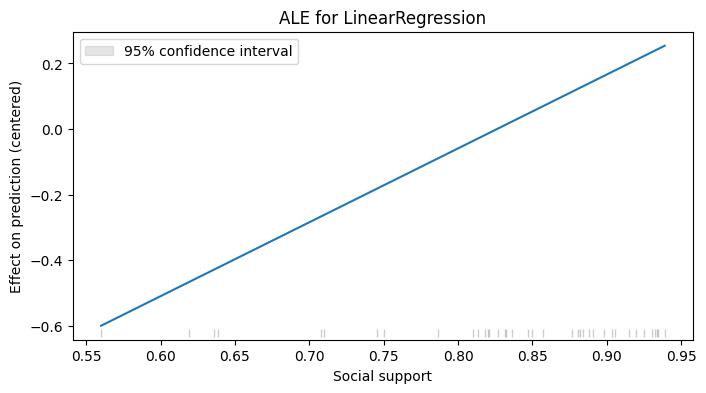

In [ ]:
from PyALE import ale
from sklearn.pipeline import make_pipeline

lr_pipe = make_pipeline(sc_minmax, lr_minmax)

ale_lr = ale(
    X=X_test,
    model=lr_pipe,
    feature=["Social support"],
    include_CI=True,
    grid_size=40,
    C=0.95
)

plt.title("ALE for LinearRegression")
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


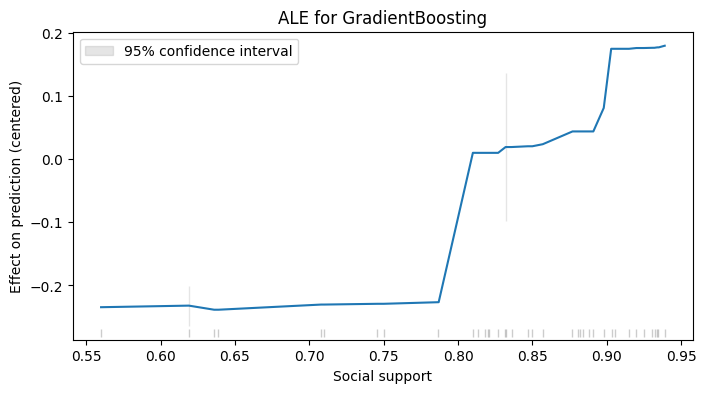

In [ ]:
gb_pipe = make_pipeline(sc_minmax, gb_minmax)

ale_gb = ale(
    X=X_test,
    model=gb_pipe,
    feature=["Social support"],
    grid_size=40,
    include_CI=True,
    C=0.95
)

plt.title("ALE for GradientBoosting")
plt.show()

## Accumulated local effects

Both models associate higher `Social support` with higher predicted happiness. The linear model yields a smooth effect, whereas gradient boosting produces a less regular curve. Confidence intervals widen in regions with fewer observations and are less uniform for the tree-based model because its local effects change at discrete thresholds.

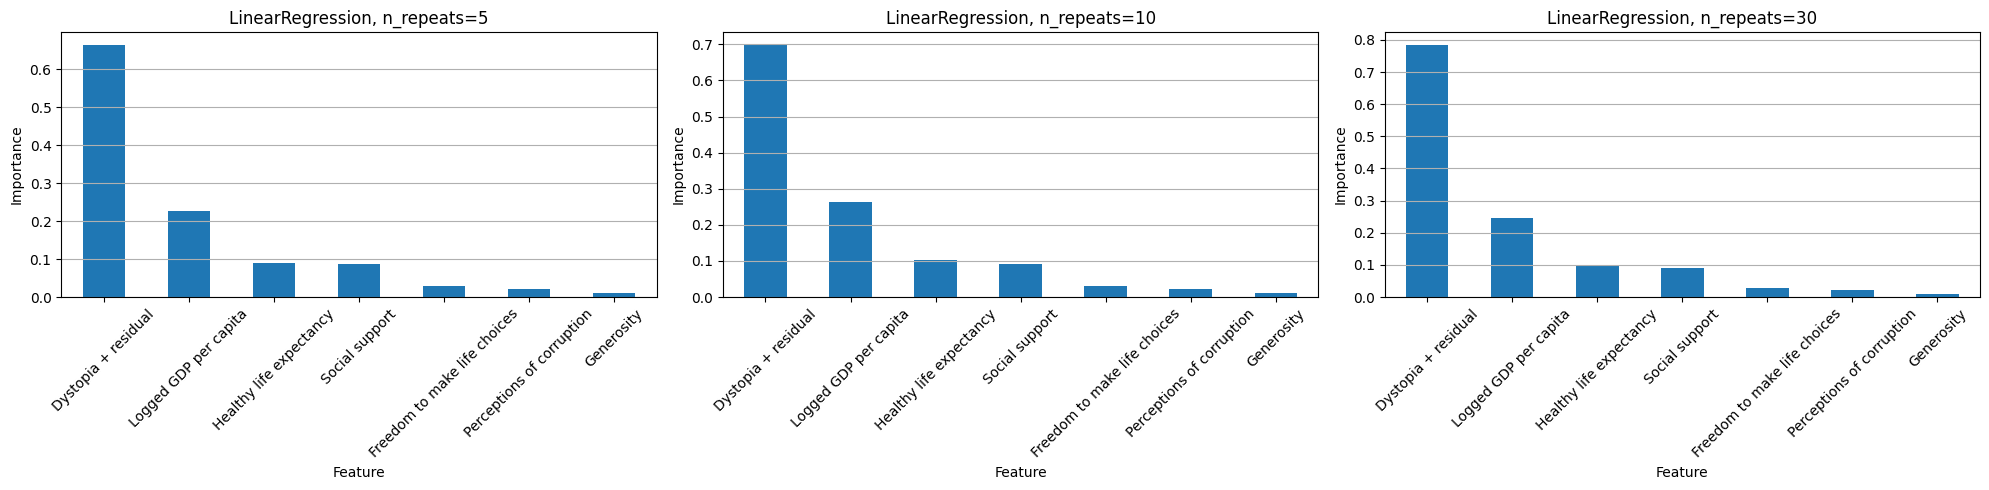

In [ ]:
from sklearn.inspection import permutation_importance

perm_lr_5 = permutation_importance(lr_pipe, X_test,y_test, n_repeats=5, scoring="neg_mean_squared_error")
perm_lr_10 = permutation_importance(lr_pipe, X_test,y_test, n_repeats=10, scoring="neg_mean_squared_error")
perm_lr_30 = permutation_importance(lr_pipe, X_test,y_test, n_repeats=30, scoring="neg_mean_squared_error")


perm_lr_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_5.importances_mean,
    "importance_std": perm_lr_5.importances_std
})

perm_lr_df = perm_lr_df.sort_values("importance", ascending=False)


perm_lr_df_5 = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_5.importances_mean,
    "importance_std": perm_lr_5.importances_std
}).sort_values("importance", ascending=False)

perm_lr_df_10 = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_10.importances_mean,
    "importance_std": perm_lr_10.importances_std
}).sort_values("importance", ascending=False)

perm_lr_df_30 = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_30.importances_mean,
    "importance_std": perm_lr_30.importances_std
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

perm_lr_df_5.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[0],
    yerr=perm_lr_df_5["importance_std"]
)
axes[0].set_title("LinearRegression, n_repeats=5")
axes[0].set_ylabel("Importance")
axes[0].set_xlabel("Feature")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y")

perm_lr_df_10.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[1],
    yerr=perm_lr_df_10["importance_std"]
)
axes[1].set_title("LinearRegression, n_repeats=10")
axes[1].set_ylabel("Importance")
axes[1].set_xlabel("Feature")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y")

perm_lr_df_30.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[2],
    yerr=perm_lr_df_30["importance_std"]
)
axes[2].set_title("LinearRegression, n_repeats=30")
axes[2].set_ylabel("Importance")
axes[2].set_xlabel("Feature")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

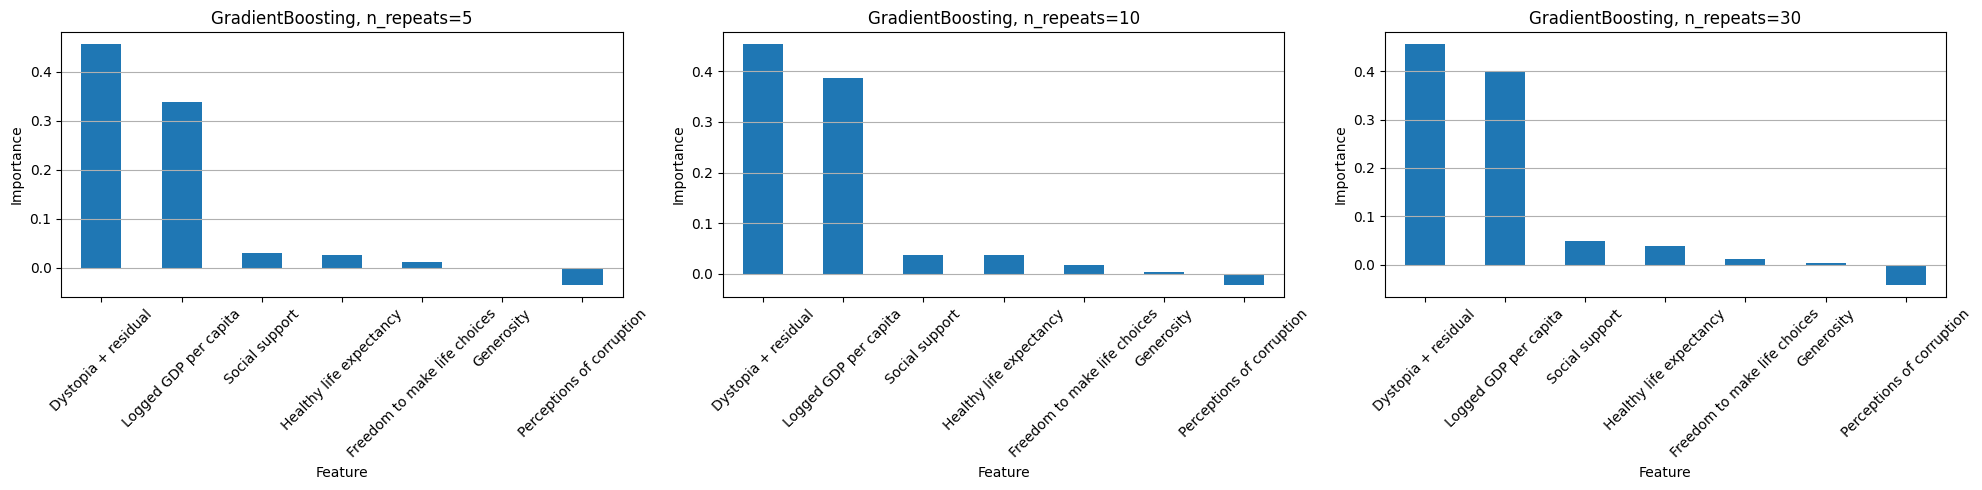

In [ ]:
from sklearn.inspection import permutation_importance

perm_lr_5 = permutation_importance(gb_pipe, X_test,y_test, n_repeats=5, scoring="neg_mean_squared_error")
perm_lr_10 = permutation_importance(gb_pipe, X_test,y_test, n_repeats=10, scoring="neg_mean_squared_error")
perm_lr_30 = permutation_importance(gb_pipe, X_test,y_test, n_repeats=30, scoring="neg_mean_squared_error")


perm_lr_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_5.importances_mean,
    "importance_std": perm_lr_5.importances_std
})

perm_lr_df = perm_lr_df.sort_values("importance", ascending=False)


perm_lr_df_5 = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_5.importances_mean,
    "importance_std": perm_lr_5.importances_std
}).sort_values("importance", ascending=False)

perm_lr_df_10 = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_10.importances_mean,
    "importance_std": perm_lr_10.importances_std
}).sort_values("importance", ascending=False)

perm_lr_df_30 = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_lr_30.importances_mean,
    "importance_std": perm_lr_30.importances_std
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

perm_lr_df_5.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[0],
    yerr=perm_lr_df_5["importance_std"]
)
axes[0].set_title("GradientBoosting, n_repeats=5")
axes[0].set_ylabel("Importance")
axes[0].set_xlabel("Feature")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y")

perm_lr_df_10.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[1],
    yerr=perm_lr_df_10["importance_std"]
)
axes[1].set_title("GradientBoosting, n_repeats=10")
axes[1].set_ylabel("Importance")
axes[1].set_xlabel("Feature")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y")

perm_lr_df_30.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[2],
    yerr=perm_lr_df_30["importance_std"]
)
axes[2].set_title("GradientBoosting, n_repeats=30")
axes[2].set_ylabel("Importance")
axes[2].set_xlabel("Feature")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

## Permutation importance

`Dystopia + residual` is dominant for linear regression; gradient boosting also assigns considerable importance to `Logged GDP per capita`. Increasing the number of permutations from a small value to several hundred leaves the ranking largely unchanged while stabilizing the estimated standard deviations.

In [ ]:
def occlusion_importance():

  betas = [0.2, 0.5, 1.0]
    
  base_values = X_train.median()
  base_pred = gb_pipe.predict(X_test)
  base_mse = mean_squared_error(y_test, base_pred)
  results = []
  
  for beta in betas:
      for feature in X_test.columns:
          X_changed = X_test.copy()
          
          X_changed[feature] = (1 - beta) * X_changed[feature] + beta * base_values[feature]
          
          y_pred_changed = gb_pipe.predict(X_changed)
          changed_mse = mean_squared_error(y_test, y_pred_changed)
          
          importance = changed_mse - base_mse
          
          results.append({
              "feature": feature,
              "beta": beta,
              "importance": importance
          })
  
  return pd.DataFrame(results)

In [ ]:
occlusion_df = occlusion_importance()
occlusion_df

,feature,beta,importance
0,Logged GDP per capita,0.2,-0.023898
1,Social support,0.2,-0.007966
2,Healthy life expectancy,0.2,-0.000488
3,Freedom to make life choices,0.2,-0.000739
4,Generosity,0.2,0.000329
5,Perceptions of corruption,0.2,0.003994
6,Dystopia + residual,0.2,-0.016363
7,Logged GDP per capita,0.5,0.070571
8,Social support,0.5,-0.021676
9,Healthy life expectancy,0.5,-0.002091


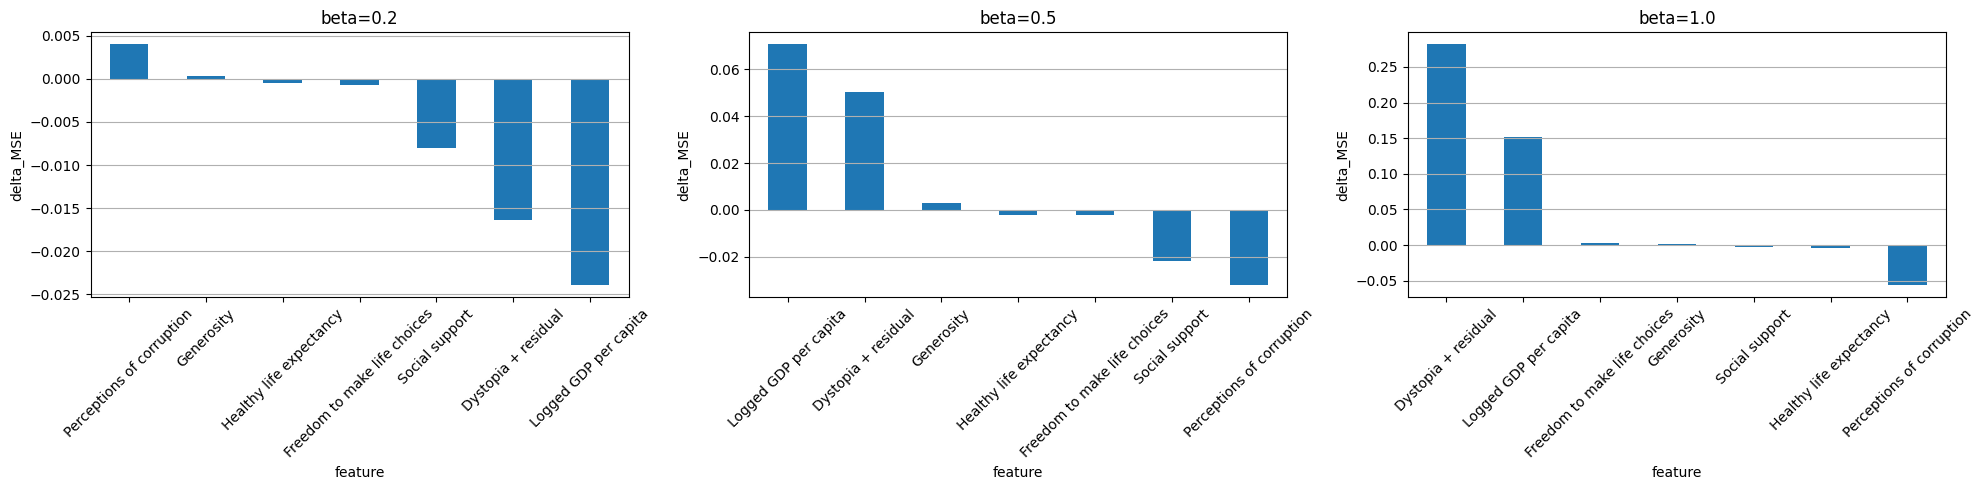

In [ ]:
occlusion_02 = occlusion_df[occlusion_df["beta"] == 0.2].sort_values("importance", ascending=False)
occlusion_05 = occlusion_df[occlusion_df["beta"] == 0.5].sort_values("importance", ascending=False)
occlusion_10 = occlusion_df[occlusion_df["beta"] == 1.0].sort_values("importance", ascending=False)

occlusion_10
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

occlusion_02.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("beta=0.2")
axes[0].set_ylabel("delta_MSE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y")

occlusion_05.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("beta=0.5")
axes[1].set_ylabel("delta_MSE")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y")

occlusion_10.set_index("feature")["importance"].plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("beta=1.0")
axes[2].set_ylabel("delta_MSE")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

## Occlusion-based importance

Moving feature values toward their medians has a larger effect as the perturbation strength increases. `Logged GDP per capita` and `Dystopia + residual` cause the largest deterioration in MSE at stronger perturbations. Negative values for several features indicate that the particular intervention can occasionally improve performance, so this measure should not be interpreted as a causal effect.

In [ ]:
import shap
import warnings
warnings.filterwarnings("ignore")
# Suppress non-actionable plotting warnings

shap.initjs()

X_train_sc_df = pd.DataFrame(X_train_sc_minmax, columns=X.columns)
X_test_sc_df = pd.DataFrame(X_test_sc_minmax, columns=X.columns)

masker = shap.maskers.Independent(data=X_train_sc_df)
explainer_lr = shap.Explainer(
    lr_minmax.predict,
    masker
)

shap_values_lr = explainer_lr(X_test_sc_df)
shap.plots.force(shap_values_lr[:100])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap:WARNING: Background dataset has 111 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=111 when initializing the masker.


In [ ]:
import warnings
warnings.filterwarnings("ignore")
# Suppress non-actionable plotting warnings
explainer_gb = shap.Explainer(
    gb_minmax.predict,
    masker
)

shap_values_gb = explainer_gb(X_test_sc_df)
shap.plots.force(shap_values_gb[:50])

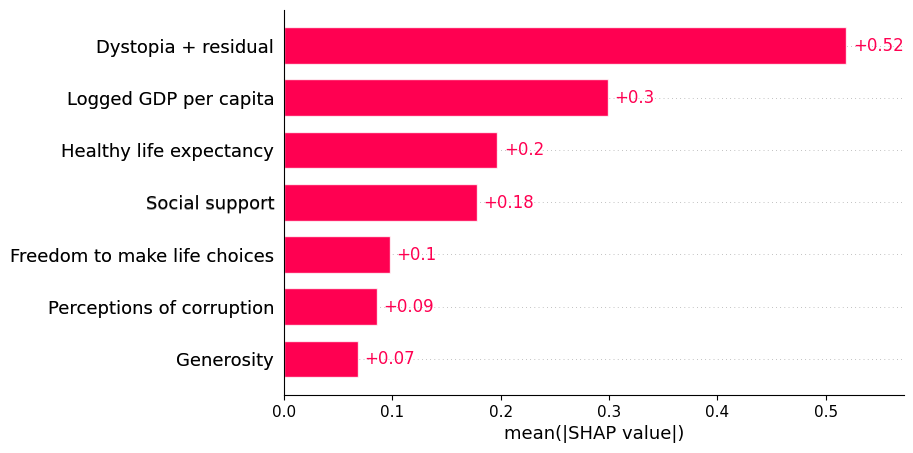

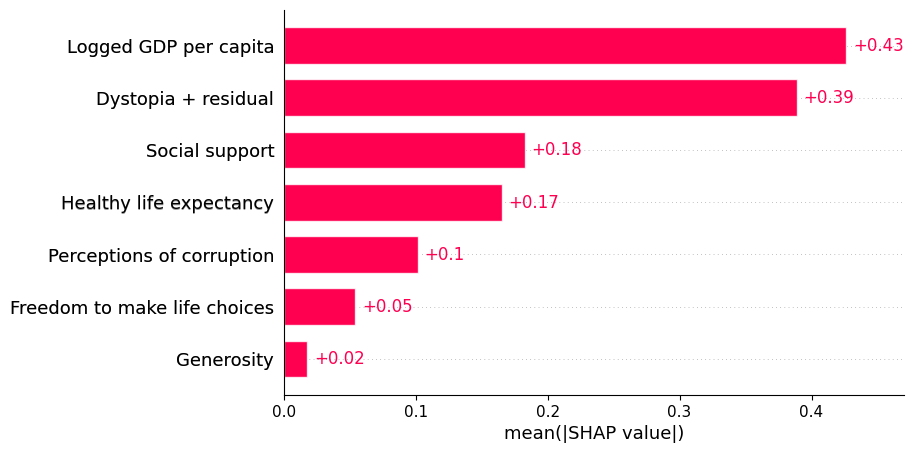

In [ ]:
shap.plots.bar(shap_values_lr)
shap.plots.bar(shap_values_gb)

## Global SHAP analysis

The global SHAP summaries broadly agree with permutation importance. Both models rely most strongly on `Dystopia + residual` and `Logged GDP per capita`, although the relative contribution of the remaining variables differs between the linear and non-linear models.

In [ ]:
shap.plots.force(shap_values_lr[7])

In [ ]:
shap.plots.force(shap_values_gb[7])

## Local SHAP analysis

For the selected observation, `Dystopia + residual` and `Logged GDP per capita` make the largest negative contributions relative to the baseline prediction. `Social support` shifts the prediction upward. The two models identify a similar set of influential variables but distribute their contributions differently because gradient boosting captures non-linear interactions.

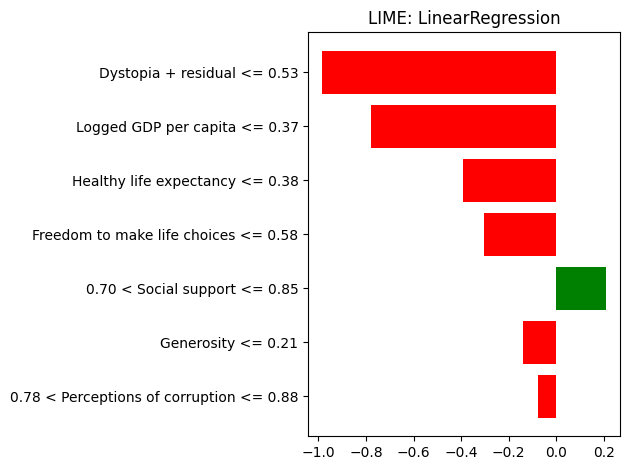

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

feature_names = list(X.columns)

explainer = LimeTabularExplainer(
    training_data=X_train_sc_minmax,
    feature_names=feature_names,
    mode="regression",
    kernel_width=np.sqrt(len(feature_names)) * 0.75,
)

x_obj = X_test_sc_minmax[7]
exp_lr = explainer.explain_instance(
    data_row=x_obj,
    predict_fn=lr_minmax.predict,
    num_features=len(feature_names)
)
fig = exp_lr.as_pyplot_figure()
plt.title("LIME: LinearRegression")
plt.tight_layout()
plt.show()

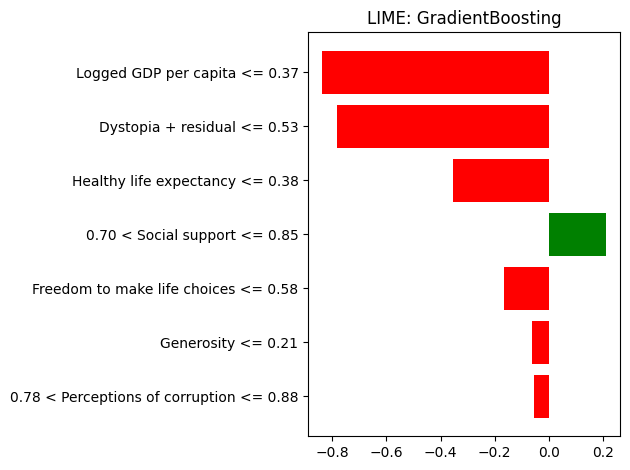

In [ ]:
exp_gb = explainer.explain_instance(
    data_row=x_obj,
    predict_fn=gb_minmax.predict,
    num_features=len(feature_names)
)

fig = exp_gb.as_pyplot_figure()
plt.title("LIME: GradientBoosting")
plt.tight_layout()
plt.show()

In [ ]:
def my_lime(model, x0, n=1000, kernel_width=None):
    d = len(x0)
    
    if kernel_width is None:
        kernel_width = np.sqrt(d) * 0.75
    
    X_near = np.random.normal(x0, 0.1, size=(n, d))
    X_near = np.clip(X_near, 0, 1)
    y_near = model.predict(X_near)
    
    distances = np.linalg.norm(X_near - x0, axis=1)
    weights = np.exp(-(distances ** 2) / (kernel_width ** 2))
    
    local_model = LinearRegression()
    local_model.fit(X_near, y_near, sample_weight=weights)
    
    return local_model.coef_

In [ ]:
x0 = X_test_sc_minmax[7]

coef_lime = my_lime(
    model=gb_minmax,
    x0=x0,
    n=1000,
    kernel_width=np.sqrt(len(feature_names)) * 0.75
)

lime_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_lime
}).sort_values("coef", key=abs, ascending=False)

lime_df

,feature,coef
1,Social support,2.196952
6,Dystopia + residual,1.734909
5,Perceptions of corruption,-1.049043
0,Logged GDP per capita,0.803731
2,Healthy life expectancy,0.596676
3,Freedom to make life choices,0.312426
4,Generosity,0.151128


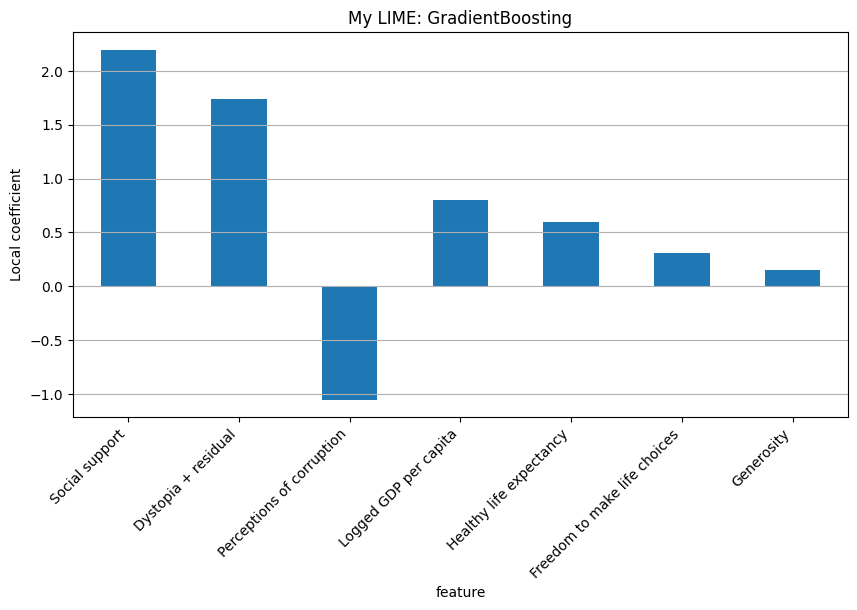

In [ ]:
lime_df.set_index("feature")["coef"].plot(kind="bar", figsize=(10, 5))

plt.title("My LIME: GradientBoosting")
plt.ylabel("Local coefficient")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## A compact LIME implementation

The local surrogate identifies `Social support` and `Dystopia + residual` as the most influential variables near the selected observation. `Perceptions of corruption` receives a negative local coefficient. These coefficients describe the fitted local neighbourhood and should not be interpreted as global or causal effects.

In [ ]:
coef_300 = my_lime(gb_minmax, x0, n=300)
coef_1000 = my_lime(gb_minmax, x0, n=1000)
coef_3000 = my_lime(gb_minmax, x0, n=3000)
coef_5000 = my_lime(gb_minmax, x0, n=5000)
coef_10000 = my_lime(gb_minmax, x0, n=10000)

stability_df = pd.DataFrame({
    "feature": feature_names,
    "n=300": coef_300,
    "n=1000": coef_1000,
    "n=3000": coef_3000,
    "n=5000": coef_5000,
    "n=10000": coef_10000,
})

stability_df

,feature,n=300,n=1000,n=3000,n=5000,n=10000
0,Logged GDP per capita,0.714803,0.913729,0.907389,0.882556,0.955509
1,Social support,1.989624,2.131112,2.172155,2.177513,2.162542
2,Healthy life expectancy,0.410347,0.551867,0.386780,0.483013,0.458598
3,Freedom to make life choices,0.126998,0.271384,0.367279,0.355779,0.299698
4,Generosity,0.218346,0.201722,0.353142,0.306457,0.260831
5,Perceptions of corruption,-1.104042,-1.037562,-1.174674,-1.135725,-1.117561
6,Dystopia + residual,1.705130,1.575793,1.592415,1.629085,1.624872


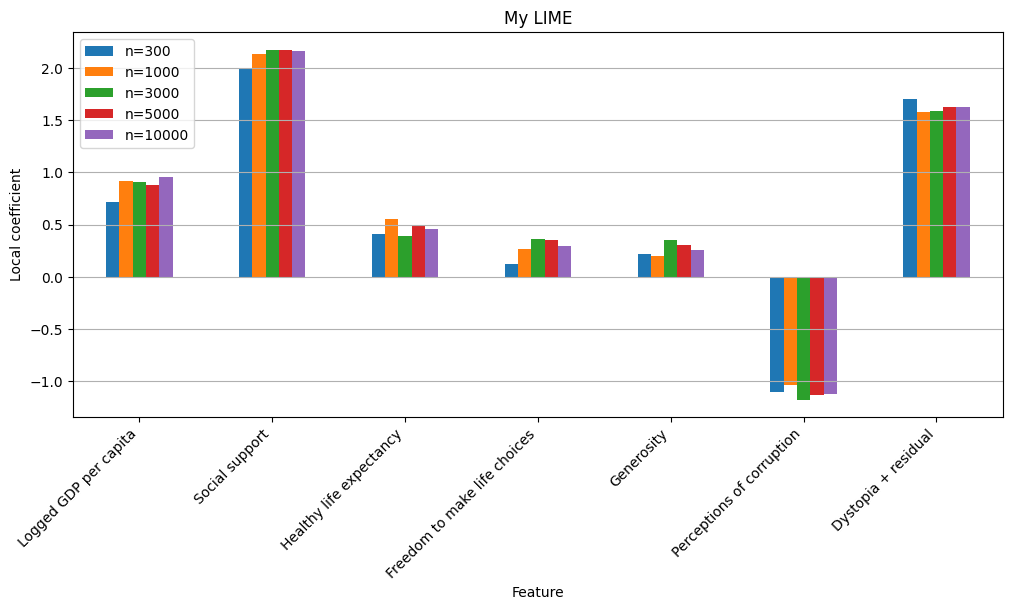

In [ ]:
stability_df.set_index("feature").plot(kind="bar", figsize=(12, 5))

plt.title("My LIME")
plt.ylabel("Local coefficient")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## LIME stability across sample sizes

With few perturbed samples, local coefficients fluctuate noticeably. They become more stable as the neighbourhood sample grows, although some variability remains because the perturbations are stochastic. This experiment highlights the importance of reporting sensitivity checks for local explanations.

In [ ]:
d = len(feature_names)

coef_kernel_0_25 = my_lime(gb_minmax,x0,n=3000,kernel_width=np.sqrt(d) * 0.25)
coef_kernel_0_75 = my_lime(gb_minmax,x0,n=3000,kernel_width=np.sqrt(d) * 0.75)
coef_kernel_1_5 = my_lime(gb_minmax,x0,n=3000,kernel_width=np.sqrt(d) * 1.5)
coef_kernel_3_0 = my_lime(gb_minmax,x0,n=3000,kernel_width=np.sqrt(d) * 3)

kernel_df = pd.DataFrame({
    "feature": feature_names,
    "0.25": coef_kernel_0_25,
    "0.75": coef_kernel_0_75,
    "1.5": coef_kernel_1_5,
    "3.0": coef_kernel_3_0
})

kernel_df

,feature,0.25,0.75,1.5,3.0
0,Logged GDP per capita,0.892430,0.938092,0.945562,0.930369
1,Social support,2.158709,2.257965,2.102141,2.109887
2,Healthy life expectancy,0.371132,0.473969,0.374578,0.282529
3,Freedom to make life choices,0.268636,0.347944,0.301189,0.321732
4,Generosity,0.161992,0.199972,0.250009,0.200898
5,Perceptions of corruption,-1.196181,-1.081545,-1.219512,-1.166295
6,Dystopia + residual,1.628138,1.712362,1.597227,1.626691


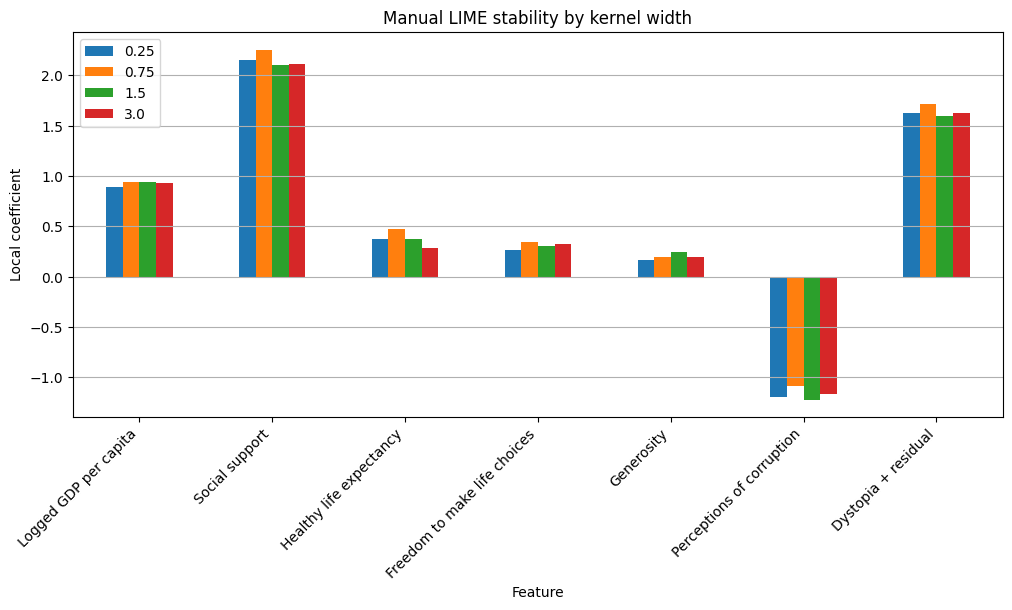

In [ ]:
kernel_df.set_index("feature").plot(kind="bar", figsize=(12, 5))

plt.title("Manual LIME stability by kernel width")
plt.ylabel("Local coefficient")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## Sensitivity to kernel width

The main ranking is reasonably stable across the tested kernel widths, with `Social support` remaining the strongest positive local contribution. Very narrow kernels emphasize the immediate neighbourhood and yield more variable coefficients; wider kernels are smoother but less strictly local.

## Limitations

The World Happiness Report includes `Dystopia + residual`, a quantity used in the construction and decomposition of the reported happiness score. Treating it as an ordinary predictive feature introduces target leakage and explains the unusually small error of the linear model. Consequently, the numerical performance in this notebook should not be interpreted as evidence of real-world predictive power.

The dataset is retained because it provides a compact illustration of interpretation methods. A deployment-oriented study should remove target-derived features, define a genuinely prospective target, and evaluate explanations under repeated resampling.

## Conclusion

Global and local explanation methods are complementary. Permutation importance and global SHAP summarize overall reliance on features, ICE/PDP/ALE describe fitted response patterns, and LIME/SHAP provide observation-level explanations. Their outputs remain model- and data-dependent, and sensitivity analysis is essential before drawing substantive conclusions.